In [1]:
import os, pathlib, datetime
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

DOWNLOADS_DIR = pathlib.Path('/mnt/c/Users/juana/Downloads').resolve()

def safe_path(p):
    try:
        p.resolve().relative_to(DOWNLOADS_DIR)
        return True
    except ValueError:
        return False

assert DOWNLOADS_DIR.exists(), f'Path not found: {DOWNLOADS_DIR}'
print(f'Target: {DOWNLOADS_DIR}')

TODAY = datetime.date.today()
records = []
for entry in DOWNLOADS_DIR.iterdir():
    if not safe_path(entry) or not entry.is_file():
        continue
    try:
        stat = entry.stat()
    except (PermissionError, OSError):
        continue
    ext = entry.suffix.lower() if entry.suffix else '(no ext)'
    size_mb = stat.st_size / (1024**2)
    modified = datetime.date.fromtimestamp(stat.st_mtime)
    records.append({'filename': entry.name, 'extension': ext,
                    'size_mb': round(size_mb, 3), 'date_modified': modified,
                    'age_days': (TODAY - modified).days})

df = pd.DataFrame(records)
print(f'Files found: {len(df)}')
print(df.head())

Target: /mnt/c/Users/juana/Downloads
Files found: 87
                                       filename extension   size_mb  \
0        android-studio-2025.1.2.13-windows.exe      .exe  1425.206   
1                                       App.jsx      .jsx     0.021   
2              avg_secure_browser_setup (1).exe      .exe     6.856   
3                  avg_secure_browser_setup.exe      .exe     6.856   
4  Backend Task 001 - Authentication System.pdf      .pdf     0.085   

  date_modified  age_days  
0    2025-08-28       259  
1    2026-05-02        12  
2    2025-12-01       164  
3    2025-11-23       172  
4    2026-03-27        48  


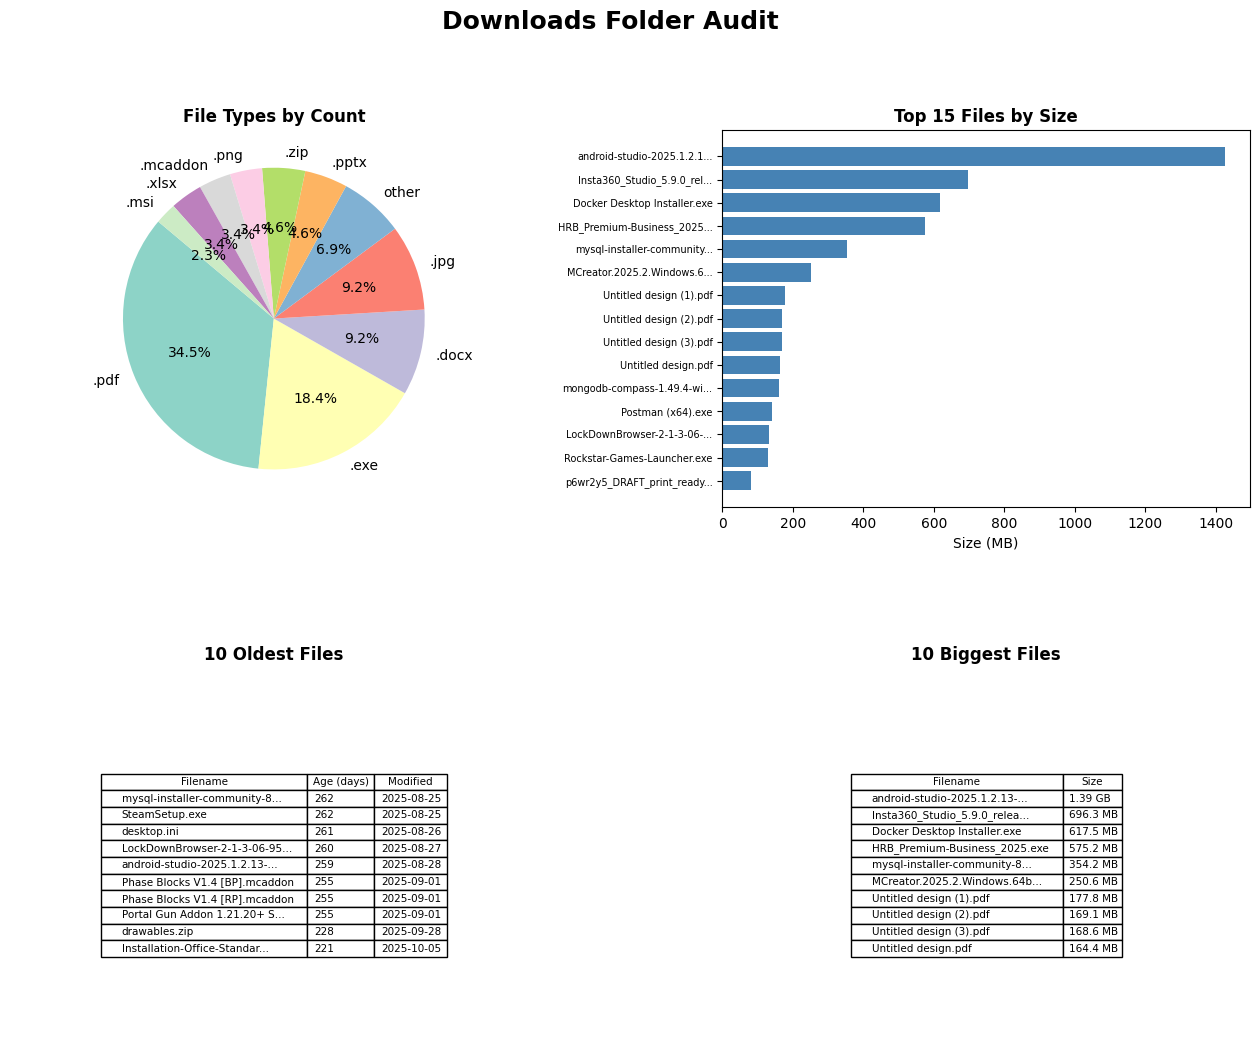

Chart saved to /tmp/downloads_audit_report.png


In [2]:
ext_counts = df['extension'].value_counts()
threshold = max(1, int(len(df) * 0.02))
small_exts = ext_counts[ext_counts <= threshold].index
pie_series = ext_counts.copy()
pie_series['other'] = pie_series[small_exts].sum()
pie_series = pie_series.drop(index=small_exts).sort_values(ascending=False)
top_size = df.nlargest(15, 'size_mb')

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Downloads Folder Audit', fontsize=18, fontweight='bold')
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax_pie = fig.add_subplot(gs[0, 0])
ax_pie.pie(pie_series.values, labels=pie_series.index, autopct='%1.1f%%',
           startangle=140, colors=plt.cm.Set3.colors[:len(pie_series)])
ax_pie.set_title('File Types by Count', fontweight='bold')

ax_bar = fig.add_subplot(gs[0, 1])
short_names = [n if len(n)<=28 else n[:25]+'...' for n in top_size['filename']]
ax_bar.barh(short_names[::-1], top_size['size_mb'].values[::-1], color='steelblue')
ax_bar.set_xlabel('Size (MB)')
ax_bar.set_title('Top 15 Files by Size', fontweight='bold')
ax_bar.tick_params(axis='y', labelsize=7)

ax_old = fig.add_subplot(gs[1, 0])
ax_old.axis('off')
oldest = df.nlargest(10, 'age_days')[['filename','age_days','date_modified']].copy()
oldest['filename'] = oldest['filename'].apply(lambda n: n if len(n)<=30 else n[:27]+'...')
oldest['date_modified'] = oldest['date_modified'].astype(str)
tbl = ax_old.table(cellText=oldest.values, colLabels=['Filename','Age (days)','Modified'],
                   cellLoc='left', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.auto_set_column_width([0,1,2])
ax_old.set_title('10 Oldest Files', fontweight='bold', pad=12)

ax_big = fig.add_subplot(gs[1, 1])
ax_big.axis('off')
biggest = df.nlargest(10, 'size_mb')[['filename','size_mb']].copy()
biggest['filename'] = biggest['filename'].apply(lambda n: n if len(n)<=30 else n[:27]+'...')
biggest['size_mb'] = biggest['size_mb'].apply(lambda v: f'{v/1024:.2f} GB' if v>=1024 else f'{v:.1f} MB')
tbl2 = ax_big.table(cellText=biggest.values, colLabels=['Filename','Size'],
                    cellLoc='left', loc='center')
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(7.5)
tbl2.auto_set_column_width([0,1])
ax_big.set_title('10 Biggest Files', fontweight='bold', pad=12)

plt.savefig('/tmp/downloads_audit_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to /tmp/downloads_audit_report.png')

In [3]:
oversized = df[df['size_mb'] >= 1024].sort_values('size_mb', ascending=False)
ancient   = df[df['age_days'] >= 365].sort_values('age_days', ascending=False)

print('=' * 60)
print(f'FILES OVER 1 GB ({len(oversized)} found)')
print('=' * 60)
for _, r in oversized.iterrows():
    print(f"  {r['size_mb']/1024:.2f} GB  |  {r['filename']}")

print()
print('=' * 60)
print(f'FILES OLDER THAN 365 DAYS ({len(ancient)} found)')
print('=' * 60)
for _, r in ancient.iterrows():
    print(f"  {r['age_days']} days  |  {r['date_modified']}  |  {r['filename']}")

print()
print('Scan complete. Nothing was modified.')

FILES OVER 1 GB (1 found)
  1.39 GB  |  android-studio-2025.1.2.13-windows.exe

FILES OLDER THAN 365 DAYS (0 found)

Scan complete. Nothing was modified.
